# **DEFENSE FIGURE — H3: the EWS null is rigorous**
---
**Purpose (thesis defense, not part of the analysis pipeline).** Produce a single
figure telling the *before / after* of the statistical correction: the rolling
variance and rolling lag-1 autocorrelation of the AMOC intensity series PC1(t) look
overwhelmingly significant under a **naïve** Kendall test (p ~ 10⁻⁴²/10⁻⁵²), but
that significance is a **pseudo-replication artefact** of overlapping windows. Once
the effective number of independent observations is counted (~19.5 non-overlapping
2-year windows), the **corrected** p-values are 0.634 and 0.595 — not significant.

This notebook is **standalone**. It does not modify NB04 — it *copies* its
data-loading and EWS logic (same `pca_vertical_scores.npz`, same 365/730-day
windows, same Isolation Forest), so the numbers are identical to the thesis.

**Output:** `../img/H3_ews_null.png` (white background) and
`../img/H3_ews_null_transparent.png` (dpi 300, transparent).

In [1]:
# --- Setup (data-loading logic copied from NB04) ---
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_CODE = NOTEBOOK_DIR.parent
if str(PROJECT_CODE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import kendalltau, norm
from sklearn.ensemble import IsolationForest

from pipeline.paths import DATA_PROCESSED

IMG_DIR = (NOTEBOOK_DIR.parent / "img")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# Reload the PCA outputs persisted by NB03 (no recomputation) — same as NB04
data = np.load(DATA_PROCESSED / "pca_vertical_scores.npz")
pc1 = data['pc1']; pc2 = data['pc2']
times = pd.to_datetime(data['times'])
pc1_series = pd.Series(pc1, index=times, name='PC1_intensity')
print(f"PC1(t): {len(pc1):,} days   {times[0].date()} -> {times[-1].date()}")
print("Figures ->", IMG_DIR.resolve())

PC1(t): 14,596 days   2004-04-02 -> 2024-03-25
Figures -> C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\04_Code\img


In [2]:
# --- Detrend (365d) then rolling variance & AR1 (730d) — identical to NB04 ---
detrend_win, var_win = 365, 730
trend    = pc1_series.rolling(detrend_win, center=True).mean()
residual = pc1_series - trend
roll_var = residual.rolling(var_win, center=True).var()   # pandas n-1 (Bessel)

def rolling_ar1(series, window):
    def ar1(x):
        x = x[~np.isnan(x)]
        if len(x) < 3:
            return np.nan
        return np.corrcoef(x[:-1], x[1:])[0, 1]
    return series.rolling(window, center=True).apply(ar1, raw=True)

roll_ar1 = rolling_ar1(residual, var_win)

# --- Naive Kendall tau (treats overlapping windows as independent) ---
def naive_kendall(ser):
    v = ser.dropna()
    return kendalltau(np.arange(len(v)), v.values)

tau_var, p_var_naive = naive_kendall(roll_var)
tau_ar1, p_ar1_naive = naive_kendall(roll_ar1)

# --- Effective N = non-overlapping 730d windows; recompute p (NB04 method) ---
res  = residual.dropna().values
N    = len(res)
n_eff = N / var_win                 # ~19.5 independent windows
def corrected_p(tau, n_eff):
    var_tau = (2 * (2*n_eff + 5)) / (9 * n_eff * (n_eff - 1))
    z = tau / np.sqrt(var_tau)
    return 2 * (1 - norm.cdf(abs(z)))
p_var_corr = corrected_p(tau_var, n_eff)
p_ar1_corr = corrected_p(tau_ar1, n_eff)

print(f"N raw residual = {N:,}   N_eff (non-overlap 730d windows) = {n_eff:.2f}")
print(f"variance : tau={tau_var:+.3f}  naive p={p_var_naive:.2e}  corrected p={p_var_corr:.3f}")
print(f"AR1      : tau={tau_ar1:+.3f}  naive p={p_ar1_naive:.2e}  corrected p={p_ar1_corr:.3f}")
print(f"AR1 range: {np.nanmin(roll_ar1):.3f} .. {np.nanmax(roll_ar1):.3f}  (high = daily inertia)")

N raw residual = 14,232   N_eff (non-overlap 730d windows) = 19.50
variance : tau=+0.078  naive p=2.12e-42  corrected p=0.634
AR1      : tau=+0.088  naive p=1.27e-52  corrected p=0.595
AR1 range: 0.900 .. 0.968  (high = daily inertia)


In [3]:
# --- Isolation Forest on PC1+PC2 (contamination 5%, seeded) — identical to NB04 ---
X_if = np.column_stack([pc1, pc2])
iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=200).fit(X_if)
is_anom = iso.predict(X_if) == -1
anom_dates = times[is_anom]

mid = len(times) // 2
n_first, n_second = int(is_anom[:mid].sum()), int(is_anom[mid:].sum())
print(f"IF flagged {is_anom.sum()} days ({100*is_anom.mean():.1f}%)")
print(f"first half (to {times[mid].date()}): {n_first}   second half: {n_second}   "
      f"-> spread across record, not end-loaded")

IF flagged 730 days (5.0%)
first half (to 2014-03-30): 445   second half: 285   -> spread across record, not end-loaded


saved: H3_ews_null.png | H3_ews_null_transparent.png


saved: H3_ews_null_no_pvalues.png | H3_ews_null_no_pvalues_transparent.png


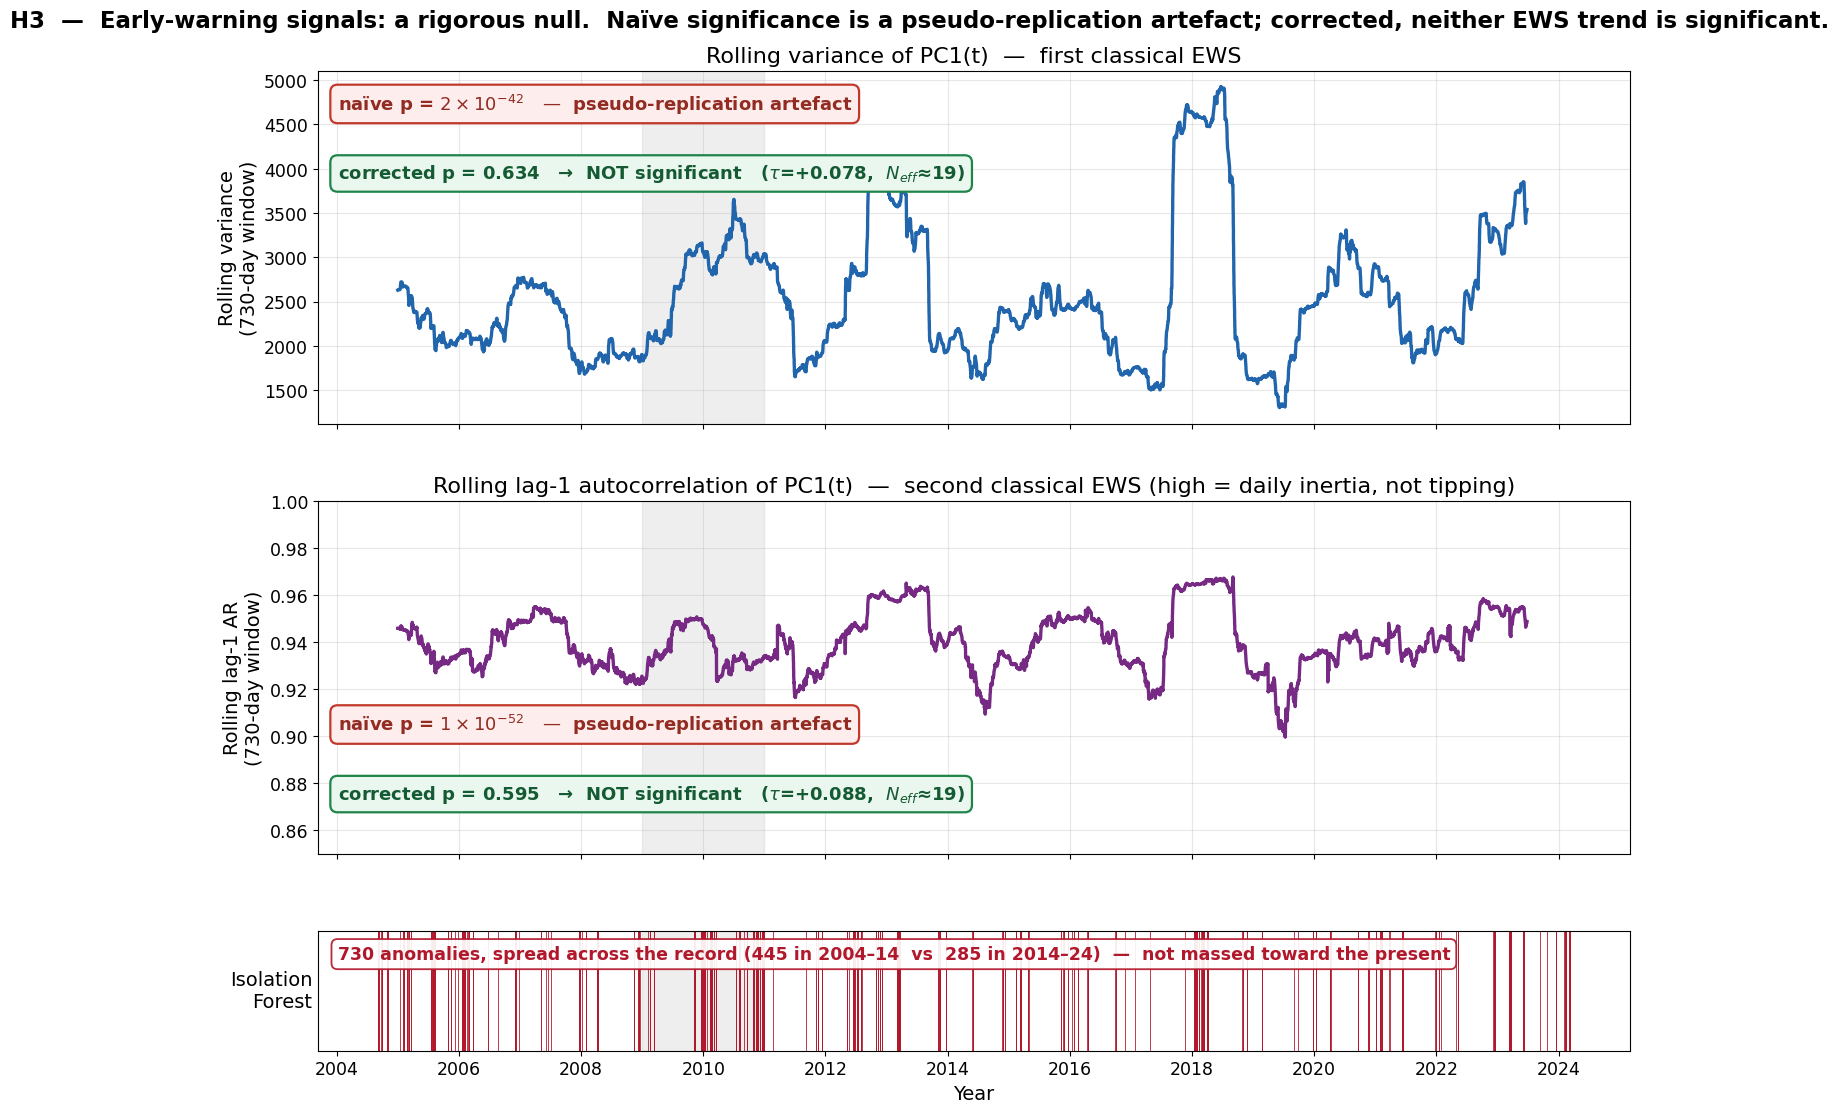

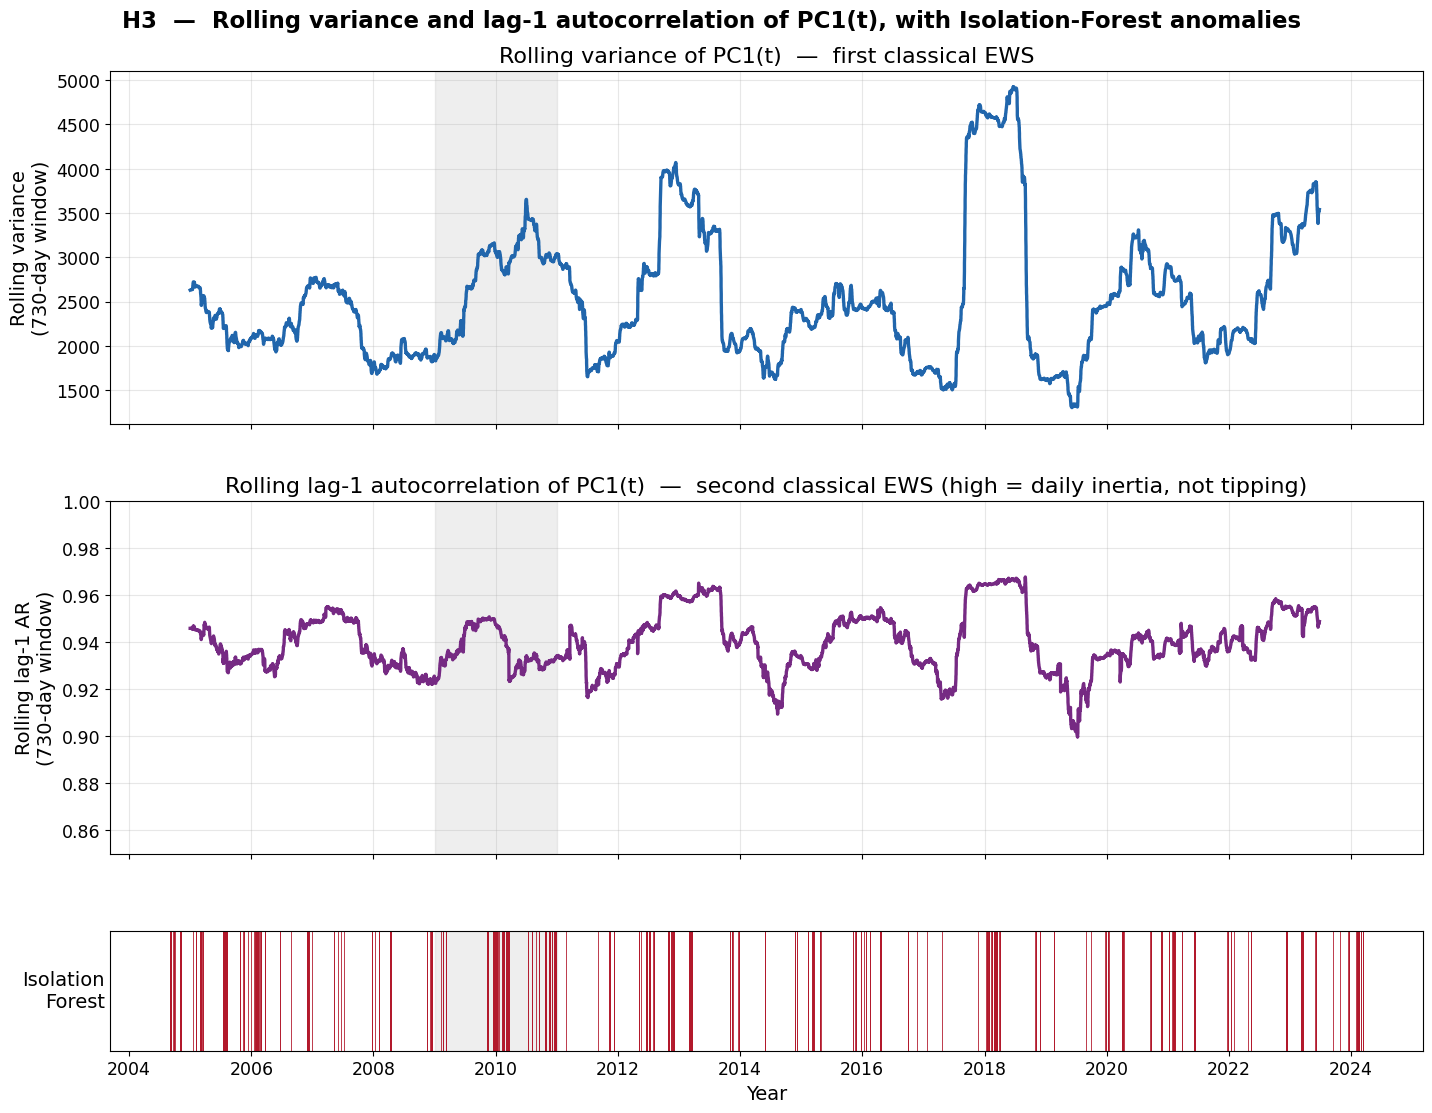

In [4]:
# --- The figure: naive vs corrected EWS + Isolation-Forest timeline ---
plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 14,
    'xtick.labelsize': 12.5, 'ytick.labelsize': 12.5, 'legend.fontsize': 13,
    'axes.grid': True, 'grid.alpha': 0.30, 'font.family': 'DejaVu Sans',
})

VAR_COLOR  = '#2166AC'      # rolling variance  — blue
AR1_COLOR  = '#762A83'      # rolling AR1       — purple
ANOM_COLOR = '#B2182B'      # anomalies         — red
EVENT_SHADE = '0.55'

def sci(p):
    # Pretty scientific notation as mathtext, e.g. 2e-42 -> $2\times10^{-42}$
    if p <= 0 or not np.isfinite(p):
        return r"$0$"
    e = int(np.floor(np.log10(p)))
    m = p / 10**e
    return rf"${m:.0f}\times10^{{{e}}}$"

def annotate_pvals(ax, tau, p_naive, p_corr, y_naive=0.94, y_corr=0.74):
    ax.text(0.015, y_naive,
            f"na\u00efve p = {sci(p_naive)}   \u2014  pseudo-replication artefact",
            transform=ax.transAxes, ha='left', va='top', fontsize=13,
            color='#922B21', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc='#FDEDEC', ec='#C0392B', lw=1.6))
    ax.text(0.015, y_corr,
            f"corrected p = {p_corr:.3f}   \u2192  NOT significant   "
            f"($\\tau$={tau:+.3f},  $N_{{eff}}$\u2248{n_eff:.0f})",
            transform=ax.transAxes, ha='left', va='top', fontsize=13,
            color='#145A32', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc='#EAF7EF', ec='#1E8449', lw=1.6))

def render_h3(show_pvalues, stub, neutral_title=False, show_if_box=True):
    fig, (axV, axA, axC) = plt.subplots(
        3, 1, figsize=(14.5, 11.2), sharex=True,
        gridspec_kw={'height_ratios': [1.0, 1.0, 0.34], 'hspace': 0.28})

    # ---- Panel A: rolling variance ----
    axV.plot(roll_var.index, roll_var.values, color=VAR_COLOR, lw=2.4)
    axV.axvspan(pd.Timestamp('2009-01-01'), pd.Timestamp('2010-12-31'),
                color=EVENT_SHADE, alpha=0.14)
    axV.set_ylabel(f'Rolling variance\n({var_win}-day window)')
    axV.set_title('Rolling variance of PC1(t)  \u2014  first classical EWS')
    if show_pvalues:
        annotate_pvals(axV, tau_var, p_var_naive, p_var_corr)

    # ---- Panel B: rolling AR1 ----
    axA.plot(roll_ar1.index, roll_ar1.values, color=AR1_COLOR, lw=2.4)
    axA.axvspan(pd.Timestamp('2009-01-01'), pd.Timestamp('2010-12-31'),
                color=EVENT_SHADE, alpha=0.14)
    axA.set_ylabel(f'Rolling lag-1 AR\n({var_win}-day window)')
    axA.set_ylim(0.85, 1.0)
    axA.set_title('Rolling lag-1 autocorrelation of PC1(t)  \u2014  second classical EWS '
                  '(high = daily inertia, not tipping)')
    if show_pvalues:
        annotate_pvals(axA, tau_ar1, p_ar1_naive, p_ar1_corr, y_naive=0.40, y_corr=0.20)

    # ---- Panel C: Isolation Forest anomaly timeline (not a p-value box) ----
    axC.vlines(anom_dates, 0, 1, color=ANOM_COLOR, lw=0.7, alpha=0.85)
    axC.axvspan(pd.Timestamp('2009-01-01'), pd.Timestamp('2010-12-31'),
                color=EVENT_SHADE, alpha=0.14)
    axC.set_yticks([])
    axC.set_ylim(0, 1)
    axC.grid(False)
    axC.set_ylabel('Isolation\nForest', rotation=0, ha='right', va='center')
    axC.set_xlabel('Year')
    if show_if_box:
        axC.text(0.015, 0.88,
                 f"{is_anom.sum()} anomalies, spread across the record "
                 f"({n_first} in 2004\u201314  vs  {n_second} in 2014\u201324)  "
                 f"\u2014  not massed toward the present",
                 transform=axC.transAxes, ha='left', va='top', fontsize=12.5,
                 color=ANOM_COLOR, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=ANOM_COLOR, lw=1.3, alpha=0.92))
    axC.xaxis.set_major_locator(mdates.YearLocator(2))
    axC.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    if neutral_title:
        _title = ('H3  \u2014  Rolling variance and lag-1 autocorrelation of PC1(t), '
                  'with Isolation-Forest anomalies')
    else:
        _title = ('H3  \u2014  Early-warning signals: a rigorous null.  '
                  'Na\u00efve significance is a pseudo-replication artefact; corrected, '
                  'neither EWS trend is significant.')
    fig.suptitle(_title, fontsize=16.5, fontweight='bold', y=0.985)
    fig.subplots_adjust(left=0.085, right=0.99, top=0.93, bottom=0.055, hspace=0.30)

    f_std   = IMG_DIR / f"{stub}.png"
    f_trans = IMG_DIR / f"{stub}_transparent.png"
    fig.savefig(f_std,   dpi=200, facecolor='white', bbox_inches='tight')
    fig.savefig(f_trans, dpi=300, transparent=True,  bbox_inches='tight')
    print("saved:", f_std.name, "|", f_trans.name)

# (1) full version, with the naive/corrected p-value boxes
render_h3(show_pvalues=True,  stub="H3_ews_null")
# (2) fully clean version: no p-value boxes, neutral title, no Isolation-Forest box
render_h3(show_pvalues=False, stub="H3_ews_null_no_pvalues",
          neutral_title=True, show_if_box=False)
plt.show()